# Correlation
### based on QCD on the Lattice Ch. 4.5.2 

In [97]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

import tools
#import thermalization

In [98]:
# read the h5-file + bootstrap
def h5_read_bootstrap(filename, n_configs, B, path = "Configuration", data_name = "plaquette"):

    means = []
    stds = []

    with h5py.File(filename, "r") as f:
        for i in range(n_configs):

            dataset = f[f"{path}/{i}/{data_name}"][:]
            mean, std = tools.bootstrap(B, dataset)

            means.append(mean)
            stds.append(std)

    return np.array(means), np.array(stds)



In [99]:
def autocorrelation(X):

    X = np.asarray(X)
    N = len(X)

    mean = np.mean(X)
    X_new= X - mean

    C = np.correlate(X_new, X_new, mode = 'full')# sum_i  X_new_i * X_new_i+t
    C = C[N-1:] # no negative t
    #norm = np.arange(N, 0, -1)
    #C = C/norm

    return C

In [100]:
def normalized_autocorrelation(X):
    
    C = autocorrelation(X)

    return C / C[0] #Gamma

In [101]:
def integrated_autocorrelation_time(Gamma):

    tau_int = 0.5
    
    for t in range(1, len(Gamma)):
        if Gamma[t] <= 0:
            break
        
        tau_int += Gamma[t]

    return tau_int


In [102]:
# t in steps of five now
def integrated_autocorrelation_time_5(Gamma):

    tau_int = 0.5
    
    for t in range(1, len(Gamma)):
        if Gamma[t] <= 0:
            break
        
        tau_int += Gamma[t]

    return tau_int*5

In [103]:
def sigma_corr(X, tau_int):
    
    X = np.asarray(X)
    N=len(X)
    sigma_2 = np.var(X, ddof=1)

    return np.sqrt(sigma_2 / N * 2 * tau_int)

#### actually get data

In [104]:
#Cold
MeanCold, StdCold = h5_read_bootstrap("../h5/ColdPlaq.h5", n_configs=2000, B=200)

N = len(MeanCold)

GammaCold = normalized_autocorrelation(MeanCold)
tau_int_cold = integrated_autocorrelation_time(GammaCold)

sigma_cold = sigma_corr(MeanCold, tau_int_cold)

# independent measurements

N_cold_indep = N / (2 * tau_int_cold)

print(tau_int_cold)
print(sigma_cold)
print(N_cold_indep)
print(N)

100.77074787031754
0.016660243791766522
9.923514721622448
2000


In [105]:
#hot
MeanHot, StdHot = h5_read_bootstrap("../h5/HotPlaq.h5", n_configs=2000, B=200)

N = len(MeanHot)

GammaHot = normalized_autocorrelation(MeanHot)
tau_int_hot = integrated_autocorrelation_time(GammaHot)

sigma_hot = sigma_corr(MeanHot, tau_int_hot)

# independent measurements

N_hot_indep = N / (2 * tau_int_hot)

print(tau_int_hot)
print(sigma_hot)
print(N_hot_indep)

29.942424132570558
0.002103186904088643
33.39742953250826


In [106]:
#ColdMultiplaq
MeanColdMulti, StdColdMulti = h5_read_bootstrap("../h5/ColdMultiPlaq.h5", n_configs=2000, B=200)

N = len(MeanCold)

GammaColdMulti = normalized_autocorrelation(MeanColdMulti)
tau_int_cold_multi = integrated_autocorrelation_time_5(GammaColdMulti)

sigma_cold_multi = sigma_corr(MeanColdMulti, tau_int_cold_multi)

# independent measurements

N_cold_multi_indep = N / (2 * tau_int_cold_multi)

print(tau_int_cold_multi)
print(sigma_cold_multi)
print(N_cold_multi_indep)
print(N)

25.501701619839313
0.008637351406171667
39.21306957893506
2000


In [107]:
#HotMultiplaq
MeanHotMulti, StdHotMulti = h5_read_bootstrap("../h5/HotMultiPlaq.h5", n_configs=2000, B=200)


N = len(MeanHot)

GammaHotMulti = normalized_autocorrelation(MeanHotMulti)
tau_int_hot_multi = integrated_autocorrelation_time_5(GammaHotMulti)

sigma_hot_multi = sigma_corr(MeanHotMulti, tau_int_hot_multi)

# independent measurements

N_hot_multi_indep = N / (2 * tau_int_hot_multi)

print(tau_int_hot_multi)
print(sigma_hot_multi)
print(N_hot_multi_indep)
print(N)

6.199279787177719
0.0008611050304618396
161.30906078289127
2000


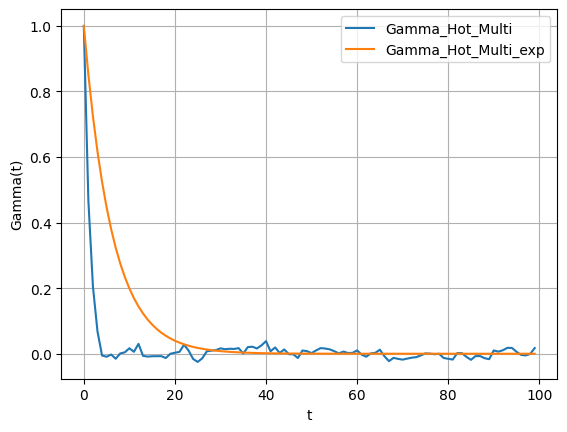

In [108]:
# plot plot plot
def Gamma_exp(t, tau):

    y = np.exp(- t / (tau))

    return y

t = np.arange(N)

plt.figure()
#plt.plot(GammaCold[:100],label="Gamma_Cold")
#plt.plot(GammaColdMulti[:100],label="Gamma_Cold_Multi")
plt.plot(GammaHotMulti[:100],label="Gamma_Hot_Multi")
#plt.plot(GammaHot[:100],label="Gamma_Hot")
#plt.plot(t[:100], Gamma_exp(t[:100], tau_int_cold), label="Gamma_Cold_exp")
plt.plot(t[:100], Gamma_exp(t[:100], tau_int_hot_multi), label="Gamma_Hot_Multi_exp")
#plt.plot(t[:100], Gamma_exp(t[:100], tau_int_hot), label="Gamma_Hot_exp")
plt.xlabel("t")
plt.ylabel("Gamma(t)")
plt.grid()
plt.legend()